# Resting Batch Face 

### Från 😐 till 😡 med Convolutional Neural Networks

----

I detta projekt utvecklas flera CNN-modell för klassificering av ansiktsuttryck med hjälp av FER-2013-datasetet. 

Notebooken går igenom hela processen från dataanalys och förbehandling till modellträning, utvärdering och prediktioner på ny data, samt en analys och reflektion kring modellernas olika resultat.

In [1]:
# --- SETUP & IMPORTS ---

import time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

from pathlib import Path

from PIL import Image

import random

import cv2

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras import regularizers
from keras.callbacks import EarlyStopping

tf.keras.utils.set_random_seed(42)

## 1. Dataanalys

### 1.1 Antal bilder

#### 1.1.1 Total, Train & Test

In [2]:
def count_images(path):
    """
    Funktion för att räkna antalet filer som slutar på .jpg eller .png i en given mapp.

    path (Path):
        En pathlib.Path-sökväg till mappen som ska "skannas"

    Returnerar totalt antal bilder hittade i mappen (och dess undermappar) (int)
    """
    return len(list(path.rglob("*.jpg"))) + len(list(path.rglob("*jpeg"))) + len(list(path.rglob("*.png")))

# Skapar sökväg till huvudmappen
data_dir = Path("data")

# Räknar antalet bilder i mapparna data, train och test
train_count = count_images(data_dir / "train")
test_count = count_images(data_dir / "test")
total_count = train_count + test_count

# Räknar ut andel 
train_percent = (train_count / total_count) * 100
test_percent = (test_count / total_count) * 100
total_percent = train_percent + test_percent

# Skapar data till statestik-tabell
stats_images = {
    "Set": ["Train", "Test", "Total"],
    "Antal bilder": [train_count, test_count, total_count],
    "Andel": [f"{train_percent:.1f}%", f"{test_percent:.1f}%", f"{total_percent:.1f}%"]
}

df_stats_images = pd.DataFrame(stats_images)

df_stats_images

,Set,Antal bilder,Andel
0,Train,28691,80.0%
1,Test,7178,20.0%
2,Total,35869,100.0%


https://docs.python.org/3/library/pathlib.html

https://www.geeksforgeeks.org/python/pathlib-module-in-python/ 

Path från pathlib är det enklare och mer moderna sättet att hantera sökvägar jämfört med os.path då pathlib hanterar sökvägarna som objekt istället för vanliga strängar. 

Path-objekt kommer med en metod rglob() vilket gör det möjligt att leta vidare i undermappar (och FER-2013 verkar inte bestå av annat än mappar hit och dit). 

Motsvarigheten till rglob() är bara glob() som "stannar" vid första mappen istället för att gå djupare ner i mappstrukturen.

rglob() returnerar en så kallad generator, vilket bara "går förbi" filerna i mapparna och lägger inte dem på minnet. 

list() behövs då för att generatorn ska faktiskt ska samla på sig alla bilder så att det sen går att räkna dem med len().

#### 1.1.2 Klasserna

In [3]:
def get_class_dataframe(folder_path, total_set_count):
    """
    Skapar en DataFrame med statistik för alla klasser (undermappar).

    folder_path:
        Sökvägen till mappen.
    
    total_set_count:
        Totala antalet bilder i den mappen (för att räkna ut andel).

    Returnerar en pd.DataFrame
    """

    stats_list = []
    stray_files_found = []

    # Loop för att gå igenom varje undermapp och ta ut statistik för den (= antalet bilder)
    for class_path in sorted(folder_path.iterdir()):
        if class_path.is_dir():
            count = count_images(class_path)
            percent = (count / total_set_count) * 100

            stats_list.append({
                "Klass": class_path.name,
                "Antal": count,
                "Andel": f"{percent:.1f}%"
            })
        else:
            stray_files_found.append(class_path.name)

    if stray_files_found:
        print(f"Meddelande för '{folder_path.name}': Det finns filer utanför mapparna.")
    else:
        print(f"Meddelande för '{folder_path.name}': Det finns inga filer utanför mapparna.")

    return pd.DataFrame(stats_list)

iterdir() "öppnar" mappen i fråga (i den här rapporten antingen "train" eller "test") och säger vilka andra mappar som finns i den, alltså klasserna. På så vis får vi klassnamnen. 

sorted() gör att loopen går igenom undermapparna i bokstavsordning (så det alltid blir samma ordning).

is_dir() kontrollerar att det är en mapp. Om det inte är en mapp läggs filen i listan stray_files_found. 

Om det är en mapp används funktionen count_images för att räkna antalet bilder för den aktuella klassmappen. 

Varje klassinformation sparas som en dictionary i listan stats_list för att det ska gå enkelt att göra en pd.DataFrame sen. 

Och på slutet så ligger det en kontroll som talar om att det finns eller inte finns lösa filer utanför mapparna. (En liten check för att se hur städad datan är)

In [4]:
# Skriver ut statistik-tabellen för "train"
df_train = get_class_dataframe(data_dir / "train", train_count)

df_train

Meddelande för 'train': Det finns inga filer utanför mapparna.


,Klass,Antal,Andel
0,angry,3977,13.9%
1,disgust,436,1.5%
2,fear,4097,14.3%
3,happy,7215,25.1%
4,neutral,4965,17.3%
5,sad,4830,16.8%
6,surprise,3171,11.1%


In [5]:
# Skriver ut statistik-tabellen för "test"
df_test = get_class_dataframe(data_dir / "test", test_count)

df_test

Meddelande för 'test': Det finns inga filer utanför mapparna.


,Klass,Antal,Andel
0,angry,958,13.3%
1,disgust,111,1.5%
2,fear,1024,14.3%
3,happy,1774,24.7%
4,neutral,1233,17.2%
5,sad,1247,17.4%
6,surprise,831,11.6%


#### 1.1.3 Slutsats kontroll av antalet bilder

- FER-2013 är vid nedladdning redan uppdelat i tränings- och testdata med en fördelning på 80 % träningsdata och 20 % testdata.
- Det finns en obalans mellan klasserna i "train" där träningsdatan till 25% består av "happy" men bara till 1,5% av "disgust". Övriga klasser är fördelade någorlunda jämnt inom spannet 11-17%.
- Den obalans som råder i "train" ser likadan ut i "test". 


### 1.2 Bildformat

In [6]:
# Går igenom ALLA bilder för att plocka ut alla olika typer av bildstorlekar, bildformat och färgskala. 
all_sizes = set()
all_formats = set()
all_modes = set()

for img_path in data_dir.rglob("*"):
    if img_path.suffix.lower() in [".jpg", ".jpeg", ".png"]:
        with Image.open(img_path) as img:
            all_sizes.add(img.size)
            all_formats.add(img.format)
            all_modes.add(img.mode)

https://docs.python.org/3/tutorial/datastructures.html#sets 

https://pillow.readthedocs.io/en/stable/reference/Image.html

https://pillow.readthedocs.io/en/stable/reference/open_files.html#file-handling

set() skapar en tom "behållare" som är lite som en lista, fast oordnad och som inte kan innehålla dubletter. Vilket passar bra när jag bara vill veta vilka olika varianter det finns, inte hur många av varje. 

img_path.suffix.lower() säkerställer att koden bara försöker bearbeta filer som faktiskt är bilder (.jpg, .jpeg, .png).

Image.open() skapar ett objekt (i det här fallet img) som gör det möjligt att göra en massa roligt med det objektet/bilden sedan, som exempelvis show() eller resize(). 

Men helt ensam gör den inte så mycket, förutom just *det* som jag vill åt: extrahera bildstorlek, bildformat och färgskala. 

Image.open() lämnar normalt filen öppen liten grann, men genom att använda with stängs den igen vilket gör att det går att kolla igenom 35 000 + bilder utan att datorn exploderar. 

In [7]:
# Skriver ut resultatet från kodcellen innan
print(f"Unika storlekar: {all_sizes}")
print(f"Unika format: {all_formats}")
print(f"Unika modes: {all_modes}")

Unika storlekar: {(48, 48)}
Unika format: {'JPEG'}
Unika modes: {'L'}


#### 1.2.1 Slutsats bildformat

Alla bilder har samma storlek (48 x 48), samma format (jpg) och är i gråskala (L) (motsvarande för färg är RGB).

### 1.3 Visuell kontroll

In [8]:
# Plocka ut fem slumpmässiga bilder från varje klass i "train" och plottar dem i samma figur
random.seed(42)

n_samples = 5
train_path = data_dir / "train"
classes = sorted([d.name for d in train_path.iterdir() if d.is_dir()])

preview_fig, axes = plt.subplots(len(classes), n_samples, figsize=(n_samples * 2.5, len(classes) * 2.5))

for i, label in enumerate(classes):
    class_dir = train_path / label
    all_imgs = list(class_dir.glob("*.jpg"))

    samples = random.sample(all_imgs, n_samples)

    for j, img_path in enumerate(samples):
        with Image.open(img_path) as img:
            ax = axes[i, j]
            ax.imshow(img, cmap="grey")
            ax.axis("off")

            if j == 0:
                ax.set_title(label, loc="left", fontweight="bold")

plt.tight_layout()

plt.close(preview_fig)

train_path = data_dir / "train" skapar en sökväg till träningsmappen. 

classes = sorted([...]) skapar en lista med namnen på alla klasser (undermappar) i bokstavsordning. (Allt som inte är en mapp ignoreras)

preview_fig, axes = ... här skapas en figur med flera rader och kolumner. Eftersom varje rad ska innehålla 5 bilder från de olika klasserna blir antalet rader hur många klasser det finns (len(classes)) och antalet kolumner blir antalet bilder som ska visas (i det här fallet n_samples = 5). 

Sedan startas en loop som går igenom varje klass. i är klassens radnummer i figuren och label är namnet på klassen. 

class_dir = train_path / label skapar en sökväg till den aktuella klassens mapp. 

Alla bilder i den aktuella mappen sparas i en lista, all_imgs. Sedan väljs fem slumpmässiga bilder i listan ut. 

Den inre loopen går igenom de fem valda bilderna. Varje bild öppnas med Image.open() och får en korrekt plats i plotten med ax = axes[i, j] där i = raden (klassen) och ju = kolumnnummer. 

ax.imshow(img) gör att bilden visas i den valda rutan i figuren. ax.axis("off") tar bort axlarna så bara bilden visas. 

Rubriken på varje rad (klassnamnet) skrivs bara ut vid den första bilden i varje rad (j == 0).

Hela figuren sparas i en variabel (preview_fig) för att kunna visa den i den kodcell man vill. Därför behövs också plt.close(preview_fig)

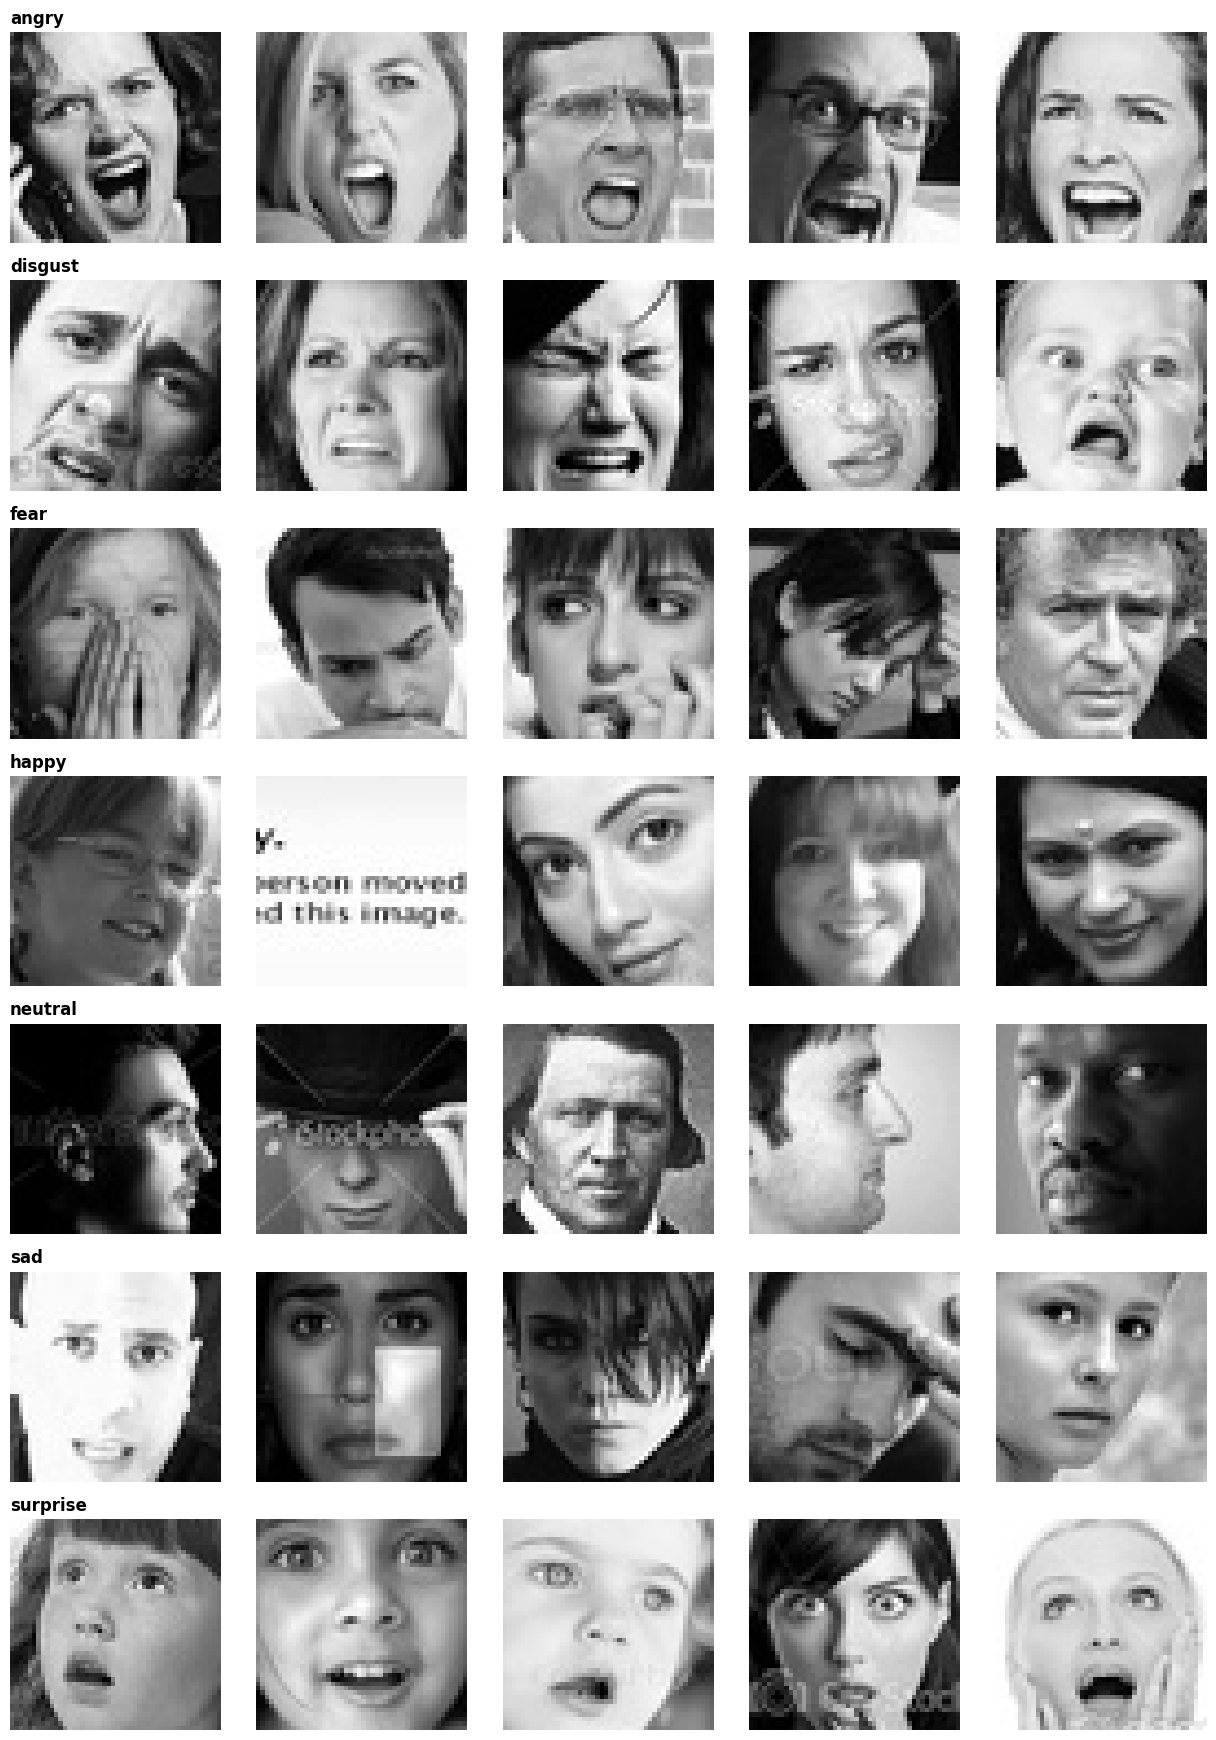

In [9]:
preview_fig

https://arxiv.org/pdf/1307.0414 (rapport om tävlingen som fick FER-2013 att uppstå)

FER-2013 togs fram i samband med en maskininlärningstävling 2013. Datasetet skapades genom att använda Google Image Search API med 184 känslorelaterade sökord, som sedan kategeoriserades i sju känsloklasser: 

- angry
- disgust
- fear
- happy
- sad
- surpries 
- neutral

Jag vill säga att detta i kombination med att tolkning av känslouttryck är subjektivt gör FER-2013 till ett svårt dataset för min NN-modell att sätta tänderna i... 

Bara i dessa 35 slumpmässiga bilder finns det brus som gör det svårt: 

- flera bilder innehåller text
- en bild hann försvinna
- varje rad innehåller minst en bild som mycket väl skulle kunna passa i en eller flera andra klasser  

## 2. Förbehandling

### 2.1 Dela upp datan i train och val

In [10]:
def create_image_df(directory_path, class_list):
    """
    Skannar en mapp och returnerar en DataFrame med bildvägar och etiketter.
    """
    all_data = []
    for cls in class_list:
        cls_dir = directory_path / cls
        if cls_dir.is_dir():
            for img_path in cls_dir.iterdir():
                if img_path.suffix.lower() in [".png", ".jpg", ".jpeg"]:
                    all_data.append({
                        "path": img_path,
                        "label": cls
                    })
    
    return pd.DataFrame(all_data)

In [11]:
base_dir = Path("data/train")
classes = ["angry", "disgust", "fear", "happy", "neutral", "sad", "surprise"]

df = create_image_df(base_dir, classes)

In [12]:
sampled_dfs = []
for cls in classes:
    cls_df = df[df["label"] == cls]
    if len(cls_df) >= 3000:
        cls_sampled = cls_df.sample(n=3000, random_state=42) # Hur säkerställer jag att allt random blir samma hela tiden? 
    else:
        cls_sampled = cls_df
    sampled_dfs.append(cls_sampled)

main_df = pd.concat(sampled_dfs).reset_index(drop=True)

In [13]:
train_df_all, val_df_all = train_test_split(
    main_df,
    test_size=0.2,
    stratify=main_df["label"],
    random_state=42
)

In [14]:
binary_classes = ["happy", "sad"]
train_df_binary = train_df_all[train_df_all["label"].isin(binary_classes)]
val_df_binary = val_df_all[val_df_all["label"].isin(binary_classes)]

In [15]:
def load_images_from_df(df, label_mapping):
    """
    Laddar bilder från DataFrames.
    """
    X = []
    y = []

    for idx, row in df.iterrows():
        img_path_str = str(row["path"])
        img = cv2.imread(img_path_str, cv2.IMREAD_GRAYSCALE)

        if img is not None:
            X.append(img)
            y.append(label_mapping[row["label"]])

    return np.array(X), np.array(y)

In [16]:
multiclass_mapping = {cls: idx for idx, cls in enumerate(classes)}
binary_mapping = {"happy": 0, "sad": 1}

In [17]:
X_train_m1, y_train_m1 = load_images_from_df(train_df_binary, binary_mapping)
X_val_m1, y_val_m1 = load_images_from_df(val_df_binary, binary_mapping)

X_train_m2, y_train_m2 = load_images_from_df(train_df_all, multiclass_mapping)
X_val_m2, y_val_m2 = load_images_from_df(val_df_all, multiclass_mapping)

In [18]:
# Kontrollerar shape
print("--- MODELL 1 (Binär: Happy & Sad) ---")
print(f"X_train_m1 shape: {X_train_m1.shape}  (Förväntat: (4800, 48, 48))")
print(f"X_val_m1   shape: {X_val_m1.shape}   (Förväntat: (1200, 48, 48))")

print("\n--- MODELL 2 (Multiclass: Alla 7) ---")
print(f"X_train_m2 shape: {X_train_m2.shape} (Förväntat: runt (14748, 48, 48))")
print(f"X_val_m2   shape: {X_val_m2.shape}  (Förväntat: runt (3688, 48, 48))")

--- MODELL 1 (Binär: Happy & Sad) ---
X_train_m1 shape: (4800, 48, 48)  (Förväntat: (4800, 48, 48))
X_val_m1   shape: (1200, 48, 48)   (Förväntat: (1200, 48, 48))

--- MODELL 2 (Multiclass: Alla 7) ---
X_train_m2 shape: (14748, 48, 48) (Förväntat: runt (14748, 48, 48))
X_val_m2   shape: (3688, 48, 48)  (Förväntat: runt (3688, 48, 48))


In [19]:
# Kontrollerar klassfördelningen
print("Modell 1 - Fördelning i träningsdatan (ska vara 2400 per klass):")
# Index 0 = happy, Index 1 = sad
print(f"Happy: {np.bincount(y_train_m1)[0]}, Sad: {np.bincount(y_train_m1)[1]}")

print("\nModell 1 - Fördelning i valideringsdatan (ska vara 600 per klass):")
print(f"Happy: {np.bincount(y_val_m1)[0]}, Sad: {np.bincount(y_val_m1)[1]}")

print("\nModell 2 - Fördelning per klass i träningsdatan:")
for cls, idx in multiclass_mapping.items():
    print(f"Klass {idx} ({cls}): {np.bincount(y_train_m2)[idx]} bilder")

print("\nModell 2 - Fördelning per klass i valideringssdatan:")
for cls, idx in multiclass_mapping.items():
    print(f"Klass {idx} ({cls}): {np.bincount(y_val_m2)[idx]} bilder")

Modell 1 - Fördelning i träningsdatan (ska vara 2400 per klass):
Happy: 2400, Sad: 2400

Modell 1 - Fördelning i valideringsdatan (ska vara 600 per klass):
Happy: 600, Sad: 600

Modell 2 - Fördelning per klass i träningsdatan:
Klass 0 (angry): 2400 bilder
Klass 1 (disgust): 348 bilder
Klass 2 (fear): 2400 bilder
Klass 3 (happy): 2400 bilder
Klass 4 (neutral): 2400 bilder
Klass 5 (sad): 2400 bilder
Klass 6 (surprise): 2400 bilder

Modell 2 - Fördelning per klass i valideringssdatan:
Klass 0 (angry): 600 bilder
Klass 1 (disgust): 88 bilder
Klass 2 (fear): 600 bilder
Klass 3 (happy): 600 bilder
Klass 4 (neutral): 600 bilder
Klass 5 (sad): 600 bilder
Klass 6 (surprise): 600 bilder


In [20]:
inverse_binary_mapping = {v: k for k, v in binary_mapping.items()}
inverse_multiclass_mapping = {v: k for k, v in multiclass_mapping.items()}

def find_indices_per_class(y_array, num_classes):
    """
    Hittar det första indexet i en y-array för varje klass.
    """
    indices_per_class = {}
    for label_siffra in range(num_classes):
        all_indices = np.where(y_array == label_siffra)[0]
        if len(all_indices) > 0:
            indices_per_class[label_siffra] = all_indices[0]
    return indices_per_class

In [21]:
# Skapar funktion för att plotta bilder i ett rutnät
def plot_images_grid(X_array, indices_dict, inverse_mapping, title, num_classes):
    """
    Plottar en bild från varje klass i ett rutnät.
    """
    cols = 2 if num_classes == 2 else 4
    rows = (num_classes + cols - 1) // cols 

    fig, axes = plt.subplots(rows, cols, figsize=(cols * 2.5, rows * 2.5))
    fig.suptitle(title, fontsize=16)
    
    axes_flat = axes.flatten() if num_classes > 1 else [axes]

    for label_siffra, idx in indices_dict.items():
        if label_siffra < len(axes_flat):
            ax = axes_flat[label_siffra]
            ax.imshow(X_array[idx], cmap="gray")
            
            label_text = inverse_mapping[label_siffra]
            ax.set_title(f"{label_text} ({label_siffra})", fontsize=12)
            ax.axis("off")
            
    for i in range(len(indices_dict), len(axes_flat)):
        axes_flat[i].axis("off")

    plt.tight_layout(rect=[0, 0, 1, 0.96]) 
    plt.show()

--- Kontroll av Modell 1 (Happy & Sad) ---


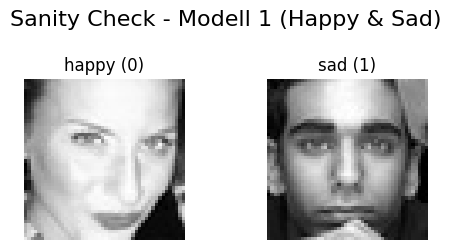

In [22]:
print("--- Kontroll av Modell 1 (Happy & Sad) ---")
indices_m1 = find_indices_per_class(y_train_m1, num_classes=2)

plot_images_grid(
    X_train_m1, 
    indices_m1, 
    inverse_binary_mapping, 
    "Sanity Check - Modell 1 (Happy & Sad)",
    num_classes=2
)

--- Kontroll av Modell 2 (Alla 7 Klasser) ---


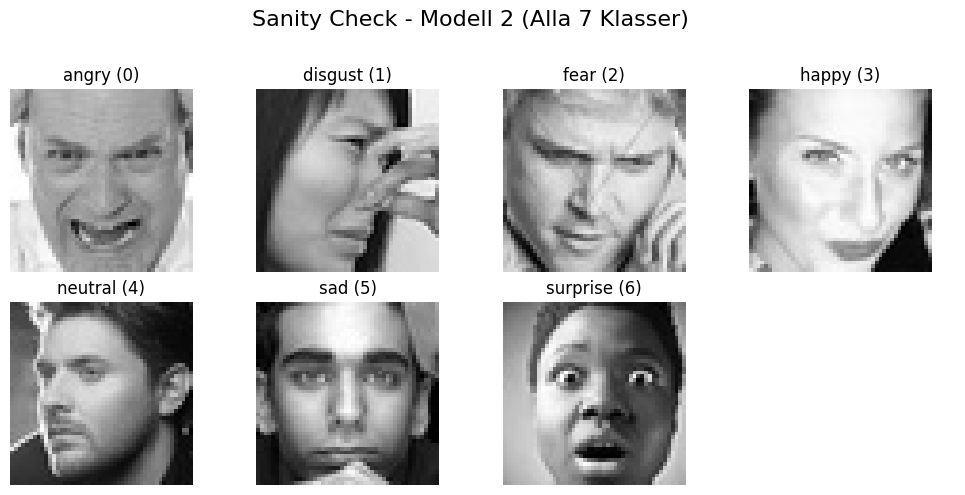

In [23]:
print("--- Kontroll av Modell 2 (Alla 7 Klasser) ---")
# Vi använder len(classes) för att dynamiskt räkna ut antal klasser (7)
num_all_classes = len(classes)
indices_m2 = find_indices_per_class(y_train_m2, num_classes=num_all_classes)

plot_images_grid(
    X_train_m2, 
    indices_m2, 
    inverse_multiclass_mapping, 
    "Sanity Check - Modell 2 (Alla 7 Klasser)",
    num_classes=num_all_classes
)

### 2.2 Testdatan

In [24]:
base_test_dir = Path("data/test")

test_df_all = create_image_df(base_test_dir, classes)

test_df_binary = test_df_all[test_df_all["label"].isin(binary_classes)]

In [25]:
X_test_m1, y_test_m1 = load_images_from_df(test_df_binary, binary_mapping)

X_test_m2, y_test_m2 = load_images_from_df(test_df_all, multiclass_mapping)

In [26]:
print("--- VERIFIERING AV TESTDATA ---")
print(f"Modell 1 (Happy/Sad) - X_test: {X_test_m1.shape}, y_test: {y_test_m1.shape}")
print(f"Modell 2 (Alla 7)    - X_test: {X_test_m2.shape}, y_test: {y_test_m2.shape}")

--- VERIFIERING AV TESTDATA ---
Modell 1 (Happy/Sad) - X_test: (3021, 48, 48), y_test: (3021,)
Modell 2 (Alla 7)    - X_test: (7178, 48, 48), y_test: (7178,)


### 2.3 Skala datan

In [27]:
# Skala bilderna till 0-1
X_train_m1_scaled = X_train_m1 / 255.0
X_val_m1_scaled = X_val_m1 / 255.0
X_test_m1_scaled = X_test_m1 / 255.0

# Lägg till färgkanalen längst bak (axis=-1)
X_train_m1_scaled = np.expand_dims(X_train_m1_scaled, axis=-1)
X_val_m1_scaled = np.expand_dims(X_val_m1_scaled, axis=-1)
X_test_m1_scaled = np.expand_dims(X_test_m1_scaled, axis=-1)

# Kontrollera formen
print(f"Data till modell 1 klar för träning! Form: {X_train_m1_scaled.shape}")
# Ska visa: (4800, 48, 48, 1)

Data till modell 1 klar för träning! Form: (4800, 48, 48, 1)


In [28]:
# Skala bilderna till 0-1
X_train_m2_scaled = X_train_m2 / 255.0
X_val_m2_scaled = X_val_m2 / 255.0
X_test_m2_scaled = X_test_m2 / 255.0

# Lägg till färgkanalen längst bak
X_train_m2_scaled = np.expand_dims(X_train_m2_scaled, axis=-1)
X_val_m2_scaled = np.expand_dims(X_val_m2_scaled, axis=-1)
X_test_m2_scaled = np.expand_dims(X_test_m2_scaled, axis=-1)

# Kontrollera formen
print(f"Data till modell 2+ klar för träning! Form: {X_train_m2_scaled.shape}")
# Ska visa: (runt 14748, 48, 48, 1)

Data till modell 2+ klar för träning! Form: (14748, 48, 48, 1)


## 3. Modellering och experiment

### Hjälpfunktioner

In [29]:
def plot_history(history, title="Träningskurvor"):
    history_df = pd.DataFrame(history.history)

    epochs = range(1, len(history_df) + 1)

    plt.figure(figsize=(12, 4))

    plt.subplot(1, 2, 1)
    plt.plot(epochs, history_df["loss"], label="Training loss")
    plt.plot(epochs, history_df["val_loss"], label="Validation loss")
    plt.xlabel("Epok")
    plt.ylabel("Loss")
    plt.title("Loss")
    plt.legend()

    plt.subplot(1, 2, 2)
    plt.plot(epochs, history_df["accuracy"], label="Training accuracy")
    plt.plot(epochs, history_df["val_accuracy"], label="Validation accuracy")
    plt.xlabel("Epok")
    plt.ylabel("Accuracy")
    plt.title("Accuracy")
    plt.legend()

    plt.suptitle(title)
    plt.tight_layout()
    plt.show()

### 3.1 Modell 1 - börja smått

#### Den allra första modellen

In [30]:
# Bygger en allra första modell 
model_1_1 = keras.Sequential([
    layers.Input(shape=(48, 48, 1)),

    layers.Conv2D(32, kernel_size=(3, 3), activation="relu", padding="same"),
    layers.MaxPooling2D(pool_size=(2, 2)),

    layers.Conv2D(64, kernel_size=(3, 3), activation="relu", padding="same"),
    layers.MaxPooling2D(pool_size=(2, 2)),

    layers.Flatten(),
    layers.Dense(128, activation="relu"),
    layers.Dense(2, activation="softmax")
])

# Komilera
model_1_1.compile(
    optimizer=keras.optimizers.Adam(learning_rate=0.001),
    loss=keras.losses.SparseCategoricalCrossentropy(),
    metrics=["accuracy"]
)

In [31]:
# Tränar modellen och sparar träningsresultatet i en history-variabel
history_1_1 = model_1_1.fit(
    X_train_m1_scaled, 
    y_train_m1,
    validation_data=(X_val_m1_scaled, y_val_m1),
    epochs=15,
    batch_size=32
)

Epoch 1/15
150/150 ━━━━━━━━━━━━━━━━━━━━ 2s 9ms/step - accuracy: 0.5492 - loss: 0.6858 - val_accuracy: 0.6267 - val_loss: 0.6437
Epoch 2/15
150/150 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - accuracy: 0.6787 - loss: 0.6030 - val_accuracy: 0.7200 - val_loss: 0.5458
Epoch 3/15
150/150 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - accuracy: 0.7425 - loss: 0.5294 - val_accuracy: 0.7525 - val_loss: 0.5097
Epoch 4/15
150/150 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - accuracy: 0.7660 - loss: 0.4790 - val_accuracy: 0.7633 - val_loss: 0.4862
Epoch 5/15
150/150 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - accuracy: 0.7937 - loss: 0.4356 - val_accuracy: 0.7742 - val_loss: 0.4678
Epoch 6/15
150/150 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - accuracy: 0.8177 - loss: 0.3936 - val_accuracy: 0.7725 - val_loss: 0.4675
Epoch 7/15
150/150 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - accuracy: 0.8410 - loss: 0.3464 - val_accuracy: 0.7775 - val_loss: 0.4689
Epoch 8/15
150/150 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - accuracy: 0.8681 - loss: 0.3013 - val_accuracy: 0.

#### Träningskurvor, den allra första modellen

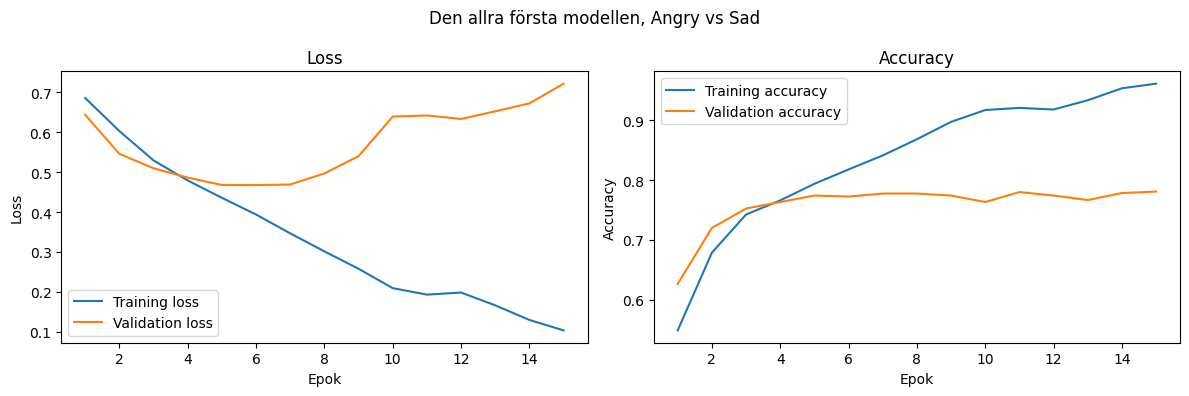

In [32]:
plot_history(history_1_1, title="Den allra första modellen, Angry vs Sad")

#### Förbättra modellen, steg 1

In [33]:
# Bygger en förbättrad modell, lägger till ett dropout-lager 
model_1_2 = keras.Sequential([
    layers.Input(shape=(48, 48, 1)),

    layers.Conv2D(32, kernel_size=(3, 3), activation="relu", padding="same"),
    layers.MaxPooling2D(pool_size=(2, 2)),

    layers.Conv2D(64, kernel_size=(3, 3), activation="relu", padding="same"),
    layers.MaxPooling2D(pool_size=(2, 2)),

    layers.Flatten(),
    layers.Dense(128, activation="relu"),

    layers.Dropout(0.5),

    layers.Dense(2, activation="softmax")
])

# Komilera
model_1_2.compile(
    optimizer=keras.optimizers.Adam(learning_rate=0.001),
    loss=keras.losses.SparseCategoricalCrossentropy(),
    metrics=["accuracy"]
)

In [34]:
# Tränar modellen och sparar träningsresultatet i en history-variabel
history_1_2 = model_1_2.fit(
    X_train_m1_scaled, 
    y_train_m1,
    validation_data=(X_val_m1_scaled, y_val_m1),
    epochs=15,
    batch_size=32
)

Epoch 1/15
150/150 ━━━━━━━━━━━━━━━━━━━━ 2s 9ms/step - accuracy: 0.5702 - loss: 0.6790 - val_accuracy: 0.6433 - val_loss: 0.6301
Epoch 2/15
150/150 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - accuracy: 0.6798 - loss: 0.6075 - val_accuracy: 0.7358 - val_loss: 0.5363
Epoch 3/15
150/150 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - accuracy: 0.7360 - loss: 0.5287 - val_accuracy: 0.7650 - val_loss: 0.4878
Epoch 4/15
150/150 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - accuracy: 0.7642 - loss: 0.4824 - val_accuracy: 0.7733 - val_loss: 0.4554
Epoch 5/15
150/150 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - accuracy: 0.7900 - loss: 0.4380 - val_accuracy: 0.7975 - val_loss: 0.4401
Epoch 6/15
150/150 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - accuracy: 0.8125 - loss: 0.3995 - val_accuracy: 0.7908 - val_loss: 0.4428
Epoch 7/15
150/150 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - accuracy: 0.8329 - loss: 0.3711 - val_accuracy: 0.7892 - val_loss: 0.4408
Epoch 8/15
150/150 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - accuracy: 0.8506 - loss: 0.3327 - val_accuracy: 0.

#### Träningskurvor, den förbättrade modellen

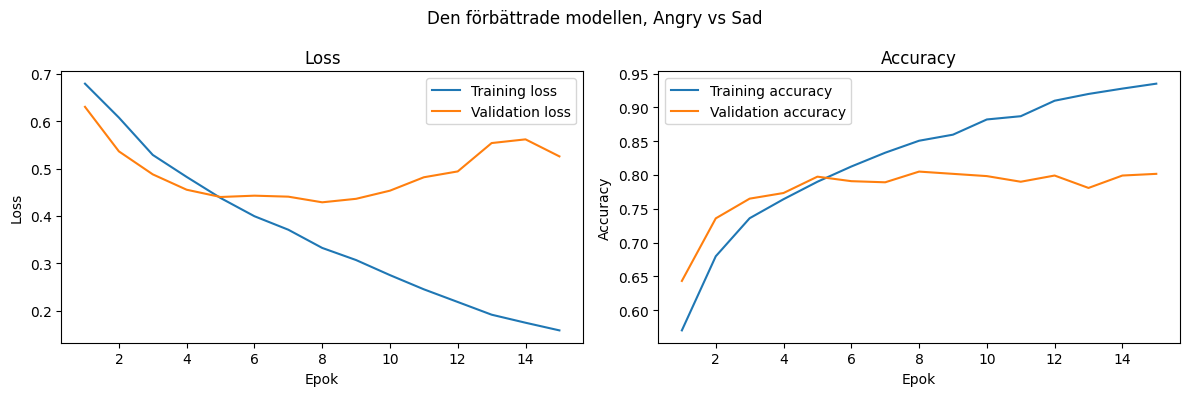

In [35]:
plot_history(history_1_2, title="Den förbättrade modellen, Angry vs Sad")

#### Förbättra modellen, steg 2

In [36]:
# Bygger en förbättrad modell 
model_1_3 = keras.Sequential([
    layers.Input(shape=(48, 48, 1)),

    layers.Conv2D(32, kernel_size=(3, 3), activation="relu", padding="same"),
    layers.MaxPooling2D(pool_size=(2, 2)),

    layers.Conv2D(64, kernel_size=(3, 3), activation="relu", padding="same"),
    layers.MaxPooling2D(pool_size=(2, 2)),

    layers.Flatten(),
    layers.Dense(128, activation="relu"),

    layers.Dropout(0.5),

    layers.Dense(2, activation="softmax")
])

# Komilera
model_1_3.compile(
    optimizer=keras.optimizers.Adam(learning_rate=0.001),
    loss=keras.losses.SparseCategoricalCrossentropy(),
    metrics=["accuracy"]
)

# Definiera Early Stopping-callback
early_stopping = EarlyStopping(
    monitor="val_loss",
    patience=3,
    restore_best_weights=True
)

In [37]:
# Tränar modellen och sparar träningsresultatet i en history-variabel
history_1_3 = model_1_3.fit(
    X_train_m1_scaled, 
    y_train_m1,
    validation_data=(X_val_m1_scaled, y_val_m1),
    epochs=15,
    batch_size=32,
    callbacks=[early_stopping]
)

Epoch 1/15
150/150 ━━━━━━━━━━━━━━━━━━━━ 2s 9ms/step - accuracy: 0.5475 - loss: 0.6895 - val_accuracy: 0.6483 - val_loss: 0.6378
Epoch 2/15
150/150 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - accuracy: 0.6433 - loss: 0.6344 - val_accuracy: 0.7125 - val_loss: 0.5642
Epoch 3/15
150/150 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - accuracy: 0.7090 - loss: 0.5656 - val_accuracy: 0.7383 - val_loss: 0.5225
Epoch 4/15
150/150 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - accuracy: 0.7392 - loss: 0.5226 - val_accuracy: 0.7575 - val_loss: 0.4979
Epoch 5/15
150/150 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - accuracy: 0.7748 - loss: 0.4741 - val_accuracy: 0.7683 - val_loss: 0.4772
Epoch 6/15
150/150 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - accuracy: 0.7852 - loss: 0.4378 - val_accuracy: 0.7642 - val_loss: 0.4703
Epoch 7/15
150/150 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - accuracy: 0.8079 - loss: 0.4050 - val_accuracy: 0.7692 - val_loss: 0.4608
Epoch 8/15
150/150 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - accuracy: 0.8254 - loss: 0.3686 - val_accuracy: 0.

#### Träningskurvor, den förbättrade modellen med Early Stopping

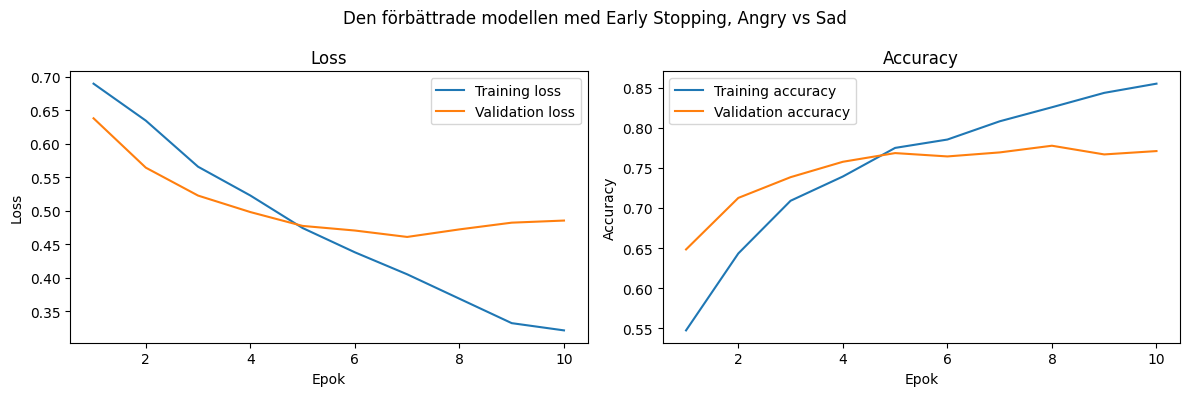

In [38]:
plot_history(history_1_3, title="Den förbättrade modellen med Early Stopping, Angry vs Sad")

#### Confusion Matrix, den förbättrade modellen

38/38 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step


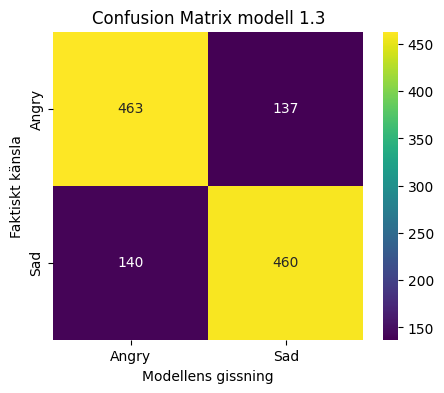

In [39]:
y_pred_probs = model_1_3.predict(X_val_m1_scaled)
y_pred = np.argmax(y_pred_probs, axis=1)

cm = confusion_matrix(y_val_m1, y_pred)

plt.figure(figsize=(5, 4))
sns.heatmap(cm, annot=True, fmt="d", cmap="viridis",
            xticklabels=["Angry", "Sad"],
            yticklabels=["Angry", "Sad"])
plt.ylabel("Faktiskt känsla")
plt.xlabel("Modellens gissning")
plt.title("Confusion Matrix modell 1.3")
plt.show()

#### Sammanställning Modell 1

In [41]:
def get_best_epoch_data(history_obj, model_name):
    hist = history_obj.history

    best_index = np.argmin(hist["val_loss"])

    return {
        "Modell": model_name,
        "Bästa epok": best_index + 1, 
        "Training Loss": hist["loss"][best_index],
        "Training Accuracy": hist["accuracy"][best_index],
        "Val Loss (lägsta)": hist["val_loss"][best_index],
        "Val Accuracy": hist["val_accuracy"][best_index]
    }

table_data = [
    get_best_epoch_data(history_1_1, "Modell 1.1 Baseline"),
    get_best_epoch_data(history_1_2, "Modell 1.2 + Dropout"),
    get_best_epoch_data(history_1_3, "Modell 1.3 + Dropout + Early Stopping")
]

summary_df = pd.DataFrame(table_data)

summary_df.style.format({
    "Training Loss": "{:.4f}",
    "Val Loss (lägsta)": "{:.4f}",
    "Training Accuracy": "{:.2%}",
    "Val Accuracy": "{:.2%}"
})

summary_df

,Modell,Bästa epok,Training Loss,Training Accuracy,Val Loss (lägsta),Val Accuracy
0,Modell 1.1 Baseline,6,0.393634,0.817708,0.467483,0.772500
1,Modell 1.2 + Dropout,8,0.332704,0.850625,0.428870,0.805000
2,Modell 1.3 + Dropout + Early Stopping,7,0.405002,0.807917,0.460777,0.769167


### 3.2 Modell 2 - déjà vu

#### 3.2.1 Transfer Learning

#### 3.2.2 Modellarkitektur

#### 3.2.3 Träning

#### 3.2.4 Resultat

### 3.3 Modell 3 - stå på egna ben

#### 3.3.1 Modellarkitektur

#### 3.3.2 Träning

#### 3.3.3 Resultat

### 3.4 Modell 4 - keep it balanced

#### 3.4.1 Modellarkitektur

#### 3.4.2 Träning

#### 3.4.3 Resultat

### 3.5 Modell 5 - klasskamp

#### 3.5.1 Data Augumentation

#### 3.5.2 Modellarkitektur

#### 3.5.3 Träning

#### 3.5.4 Resultat

## 4. Utvärdering

## 5. Prediktioner på ny data

## 6. Analys av resultatet

## 7. Reflektion